In [2]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict

In [4]:
#define the state
class Gradestate(TypedDict):
    sub1: int
    sub2: int
    sub3: int
    average: float
    grade: str

In [9]:
def calculate_average(state: Gradestate) -> Gradestate:
    sub1 = state["sub1"]
    sub2 = state["sub2"]
    sub3 = state["sub3"]
    avg = (sub1 + sub2 + sub3) / 3

    return {"average": avg}

In [11]:
def grade_calculator(state: Gradestate) -> Gradestate:
    average = state["average"]

    if average >= 90:
        grade = "A"
    elif average >= 80:
        grade = "B"
    elif average >= 70:
        grade = "C"
    elif average >= 60:
        grade = "D"
    else:
        grade = "F"

    return {"grade": grade}

In [12]:
#define the graph
graph = StateGraph(Gradestate)

#add a node
graph.add_node("calculate_average", calculate_average)
graph.add_node("grade_calculator", grade_calculator)

#add a edges
graph.add_edge(START, "calculate_average")
graph.add_edge("calculate_average", "grade_calculator")
graph.add_edge("grade_calculator", END)

#compile the graph
workflow = graph.compile()

In [13]:
#execute the graph

workflow.invoke({
    "sub1": 85,
    "sub2": 92,
    "sub3": 78
})

{'sub1': 85, 'sub2': 92, 'sub3': 78, 'average': 85.0, 'grade': 'B'}

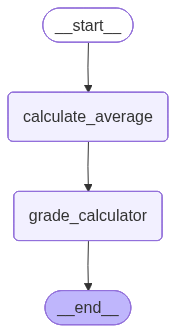

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())